### Step 1: Load the Libraies and Data

In [533]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from numpy.linalg import lstsq
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score , mean_absolute_percentage_error, root_mean_squared_error
from keras.layers import LSTM, Dense, Dropout, GRU, Conv1D, SimpleRNN
from keras.callbacks import EarlyStopping 
from keras.regularizers import l2

In [534]:
# extracting the data 
data = pd.read_csv(".\datasets\T1.csv")
data.head()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\aalma\AppData\Local\Temp\ipykernel_11592\1502131984.py:2: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_csv(".\datasets\T1.csv")


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


## Section 1: Data Description

In [535]:
# data decsription (we can see that the data is not normalized) 
data.describe()

,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
count,50530.000000,50530.000000,50530.000000,50530.000000
mean,1307.684332,7.557952,1492.175463,123.687559
std,1312.459242,4.227166,1368.018238,93.443736
min,-2.471405,0.000000,0.000000,0.000000
25%,50.677890,4.201395,161.328167,49.315437
50%,825.838074,7.104594,1063.776283,73.712978
75%,2482.507568,10.300020,2964.972462,201.696720
max,3618.732910,25.206011,3600.000000,359.997589


In [536]:
# data information (Data types, missing values, etc.)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date/Time                      50530 non-null  object 
 1   LV ActivePower (kW)            50530 non-null  float64
 2   Wind Speed (m/s)               50530 non-null  float64
 3   Theoretical_Power_Curve (KWh)  50530 non-null  float64
 4   Wind Direction (°)             50530 non-null  float64
dtypes: float64(4), object(1)
memory usage: 1.9+ MB


In [537]:
data.isnull().sum()

Date/Time                        0
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64

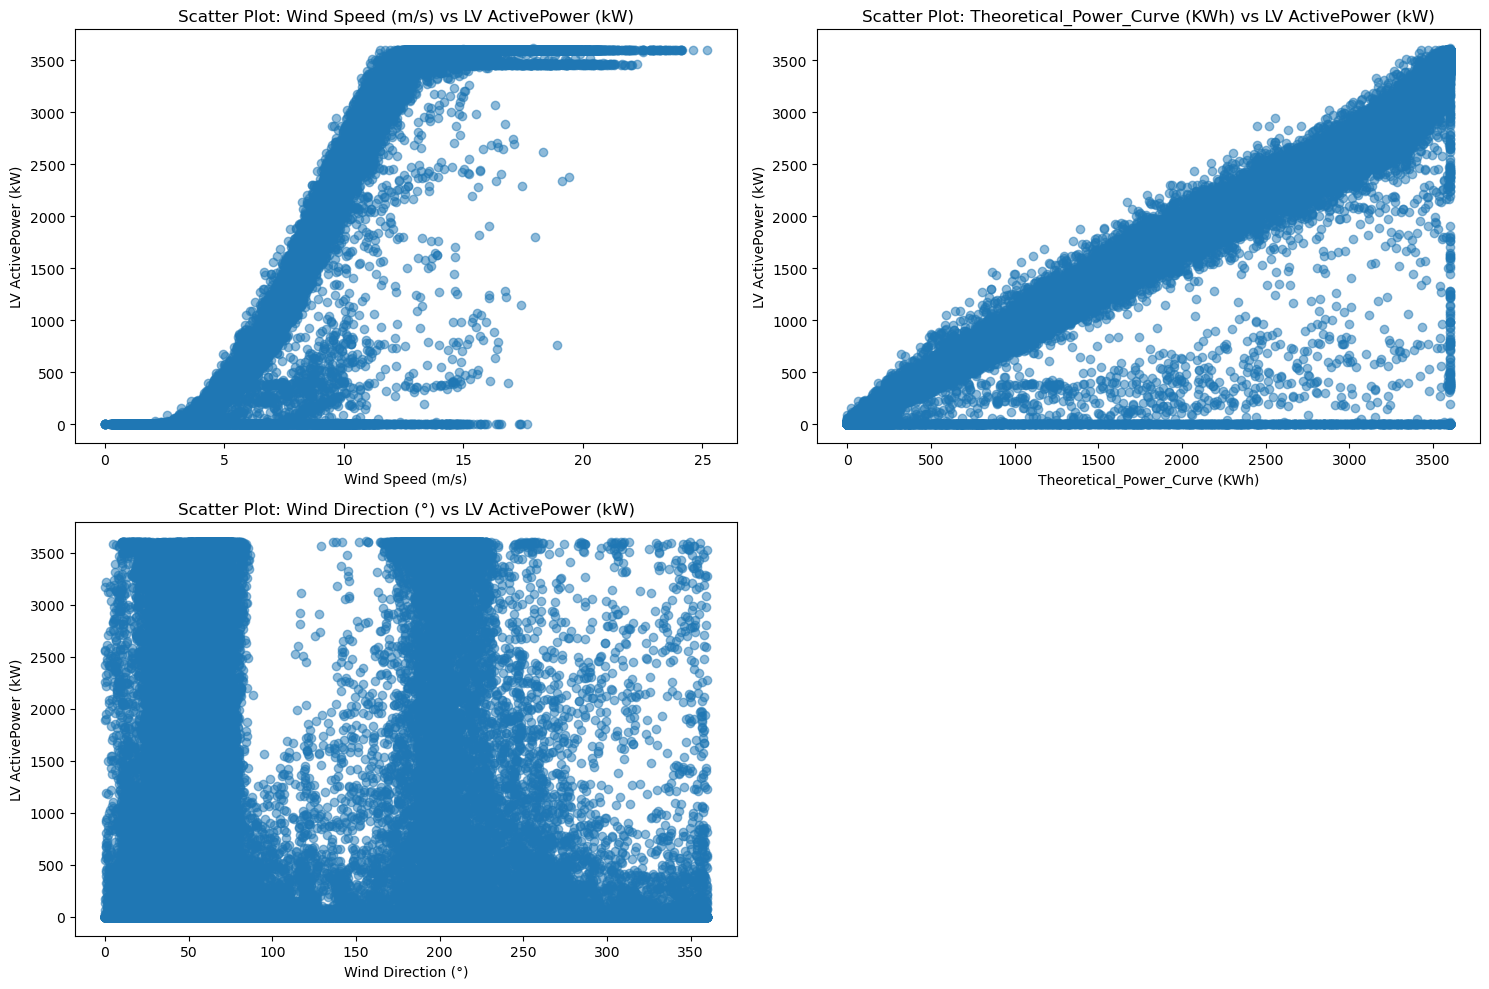

In [538]:
# using the scatter plot
target = 'LV ActivePower (kW)'
features = ['Wind Speed (m/s)', 'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)']

#plots
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(2, 2, i+1)  
    plt.scatter(data[feature], data[target], alpha=0.5)
    plt.title(f'Scatter Plot: {feature} vs {target}')
    plt.xlabel(feature)
    plt.ylabel(target)

plt.tight_layout()
plt.show()

 ## Section 3: Data Visualization

In [539]:
# Spliting the date time in year, month, days, hours and minutes
data['Year']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[0])
data['Month']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[1])
data['Day']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[2])
data['Time_Hours']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[3])
data['Time_Minutes']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[4])
data.head(5)

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Year,Month,Day,Time_Hours,Time_Minutes
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904,2018,1,1,0,0
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113,2018,1,1,0,10
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789,2018,1,1,0,20
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087,2018,1,1,0,30
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286,2018,1,1,0,40


C:\Users\aalma\AppData\Local\Temp\ipykernel_11592\3440136882.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data.iloc[:,i+1], shade=True)
C:\Users\aalma\AppData\Local\Temp\ipykernel_11592\3440136882.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data.iloc[:,i+1], shade=True)
C:\Users\aalma\AppData\Local\Temp\ipykernel_11592\3440136882.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data.iloc[:,i+1], shade=True)
C:\Users\aalma\AppData\Local\Temp\ipykernel_11592\3440136882.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; pl

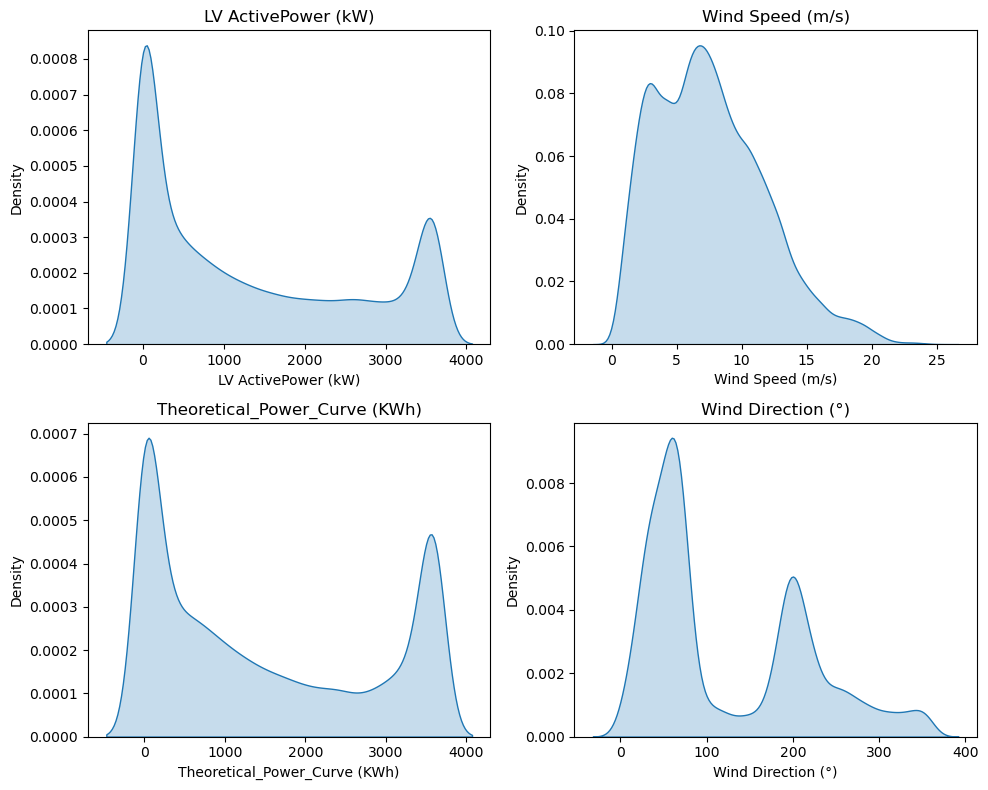

In [540]:
# plot the kde of the data
plt.figure(figsize=(10, 8))
for i in range(4):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(data.iloc[:,i+1], shade=True)
    plt.title(data.columns[i+1])
plt.tight_layout()
plt.show()

In [541]:
# convert a datetime to a timestamp
data['Date/Time'] = pd.to_datetime(data['Date/Time'], format='%d %m %Y %H:%M')
data


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Year,Month,Day,Time_Hours,Time_Minutes
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904,2018,1,1,0,0
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113,2018,1,1,0,10
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789,2018,1,1,0,20
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087,2018,1,1,0,30
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286,2018,1,1,0,40
...,...,...,...,...,...,...,...,...,...,...
50525,2018-12-31 23:10:00,2963.980957,11.404030,3397.190793,80.502724,2018,12,31,23,10
50526,2018-12-31 23:20:00,1684.353027,7.332648,1173.055771,84.062599,2018,12,31,23,20
50527,2018-12-31 23:30:00,2201.106934,8.435358,1788.284755,84.742500,2018,12,31,23,30
50528,2018-12-31 23:40:00,2515.694092,9.421366,2418.382503,84.297913,2018,12,31,23,40


## Section 4: Preprocessing Data (Selecting the target, features, scaling, splitting)

In [542]:
x = [1]  # Convert x to a list
data1 = data.loc[data['Month'].isin(x)]  # selecting the data for the month x
data1 = data1.reset_index(drop=True)  # resetting the index
data1 = data1.dropna()  # dropping the missing values

# Extract relevant columns for multivariate time series
input_features = data1['Wind Speed (m/s)']
target = data1['LV ActivePower (kW)']

In [543]:
# Scale the input features and target
scaler_x = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_scaled = scaler_x.fit_transform(input_features.values.reshape(-1, 1))
y_scaled = scaler_y.fit_transform(target.values.reshape(-1, 1))

In [544]:
# Shape of the X_scaled and y_scaled
print(f"Shape of X_scaled: {X_scaled.shape}")
print(f"Shape of y_scaled: {y_scaled.shape}")

Shape of X_scaled: (3817, 1)
Shape of y_scaled: (3817, 1)


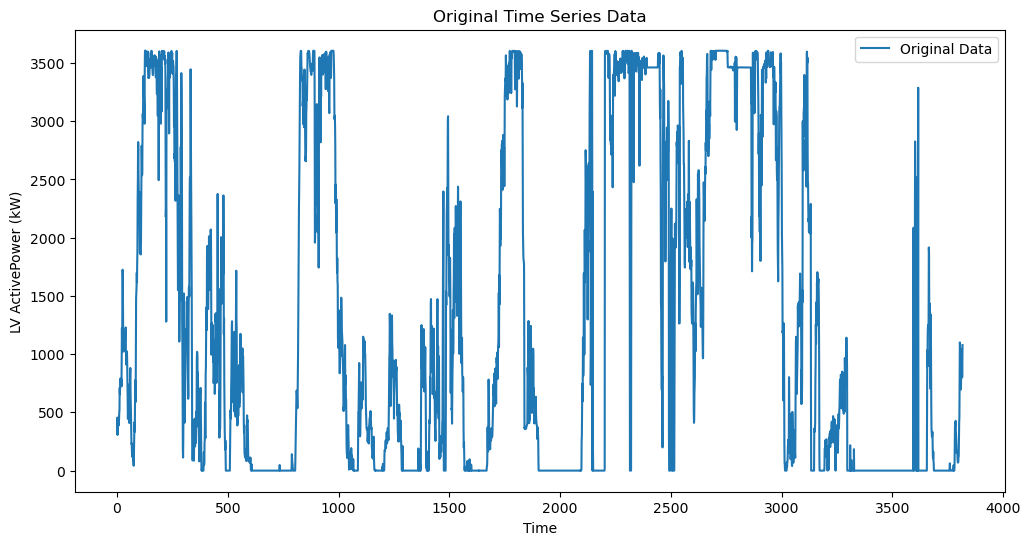

In [545]:
# Plot the original time series data
plt.figure(figsize=(12, 6))
plt.plot(data1.index, data1['LV ActivePower (kW)'].values, label='Original Data')
plt.title('Original Time Series Data')
plt.xlabel('Time')
plt.ylabel('LV ActivePower (kW)')
plt.legend()
plt.show()

In [546]:
# Update the create_xy function to handle multivariate input
def create_xy(data_x, data_y, input_length, output_length):
    x, y = [], []
    for i in range(len(data_x) - input_length - output_length + 1):
        x.append(data_x[i:i + input_length, :])
        y.append(data_y[i + input_length:i + input_length + output_length])
    return np.array(x), np.array(y)

In [547]:
# Set input and output lengths
input_length = 6
output_length = 1

# Create input-output pairs
X, y = create_xy(X_scaled, y_scaled, input_length, output_length)

# Split into training and testing data
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Shape of the training and testing data
print(f"Shape of X_train: {X_train.shape} | Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape} | Shape of y_test: {y_test.shape}")

Shape of X_train: (3048, 6, 1) | Shape of y_train: (3048, 1, 1)
Shape of X_test: (763, 6, 1) | Shape of y_test: (763, 1, 1)


## Section 1: building the model

In [548]:
def create_model(units, layer_type):
    model = Sequential()
    
    model.add(layer_type(units=units, dropout=0.05, return_sequences=True,
                         input_shape=(X_train.shape[1], X_train.shape[2]),kernel_regularizer=l2(0.01)))
    model.add(Dropout(0.2))
    
    model.add(layer_type(units=units, dropout=0.2))
    
    model.add(Dense(units=1))
    
    optimizer = keras.optimizers.Adam(learning_rate=0.001)
    model.compile(loss='mse', optimizer=optimizer)
    return model

# models
model_rnn = create_model(32, SimpleRNN)

c:\Users\aalma\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [549]:
# Fit models
def fit_model(model):
    early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 7)

    
    history = model.fit(X_train, y_train, epochs = 30, validation_split = 0.2,
                    batch_size = 64, shuffle = False, callbacks = [early_stop])
    return history

In [550]:
history_rnn = fit_model(model_rnn)

Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.3027 - val_loss: 0.0955
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1181 - val_loss: 0.1148
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0993 - val_loss: 0.1107
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0983 - val_loss: 0.1125
Epoch 5/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0895 - val_loss: 0.1383
Epoch 6/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0902 - val_loss: 0.1615
Epoch 7/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0944 - val_loss: 0.1364
Epoch 8/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0805 - val_loss: 0.1489


## Section 2: Training the models

## Section 3: Viuslization of train and validation loss

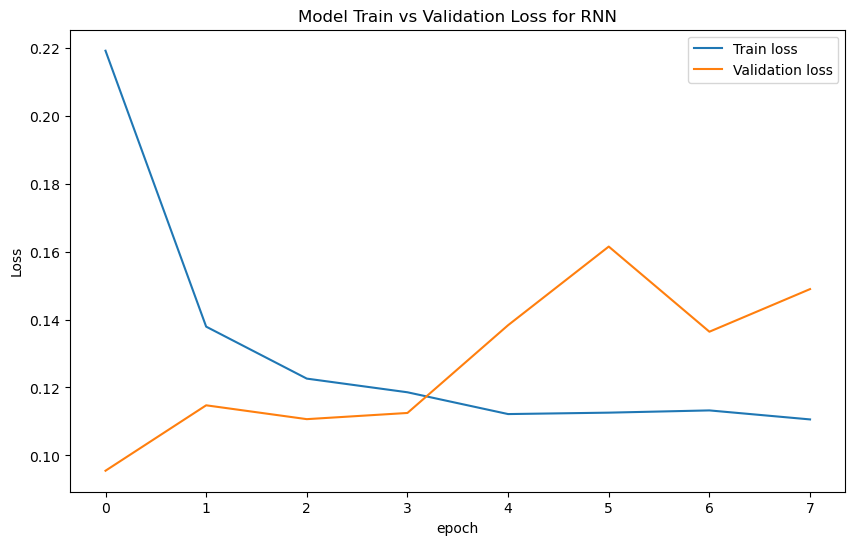

In [551]:
def plot_loss (history, model_name):
    plt.figure(figsize = (10, 6))
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Train vs Validation Loss for ' + model_name)
    plt.ylabel('Loss')
    plt.xlabel('epoch')
    plt.legend(['Train loss', 'Validation loss'], loc='upper right')
    plt.show()

# Plot loss
plot_loss (history_rnn, 'RNN')

### Step 4: Evaluation and Visulization

In [552]:
# Note that we have to use scaler_y
y_test = scaler_y.inverse_transform(y_test.reshape(y_test.shape[0], y_test.shape[1]))
y_train = scaler_y.inverse_transform(y_train.reshape(y_train.shape[0], y_train.shape[1]))

In [553]:
def prediction(model):
    prediction = model.predict(X_test)
    prediction = scaler_y.inverse_transform(prediction)
    prediction = prediction.reshape(y_test.shape)  # Reshape the prediction to match the shape of y_test
    return prediction

prediction_rnn = prediction(model_rnn)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


In [554]:
# Print the Shape of the predictions and y_test
print(f"Shape of predictions: {prediction_rnn.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of predictions: (763, 1)
Shape of y_test: (763, 1)


In [555]:
# Create a DataFrame for the actual and predicted values
comparison_df = pd.DataFrame({
    'Actual': y_test.flatten(),    
    'RNN_Prediction': prediction_rnn.flatten() 
})

# Display the first 10 elements of the DataFrame
comparison_df.head(10)

,Actual,RNN_Prediction
0,112.291801,-80.380127
1,151.325699,-25.550852
2,270.133606,9.145546
3,256.048309,116.156471
4,344.910889,173.751160
5,170.842804,160.064056
6,150.809692,95.601997
7,110.070801,15.419638
8,438.949890,-15.368565
9,637.485291,67.194252


In [556]:
# Evaluate the model
def evaluate_model(predictions, actual):
    rmse = np.sqrt(mean_squared_error(actual, predictions))
    mae = mean_absolute_error(actual, predictions)
    r2 = r2_score(actual, predictions)
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE: {mae:.3f}")
    print(f"R^2 Score: {r2:.3f}")

evaluate_model(prediction_rnn, y_test)

RMSE: 831.196
MAE: 691.976
R^2 Score: -0.372


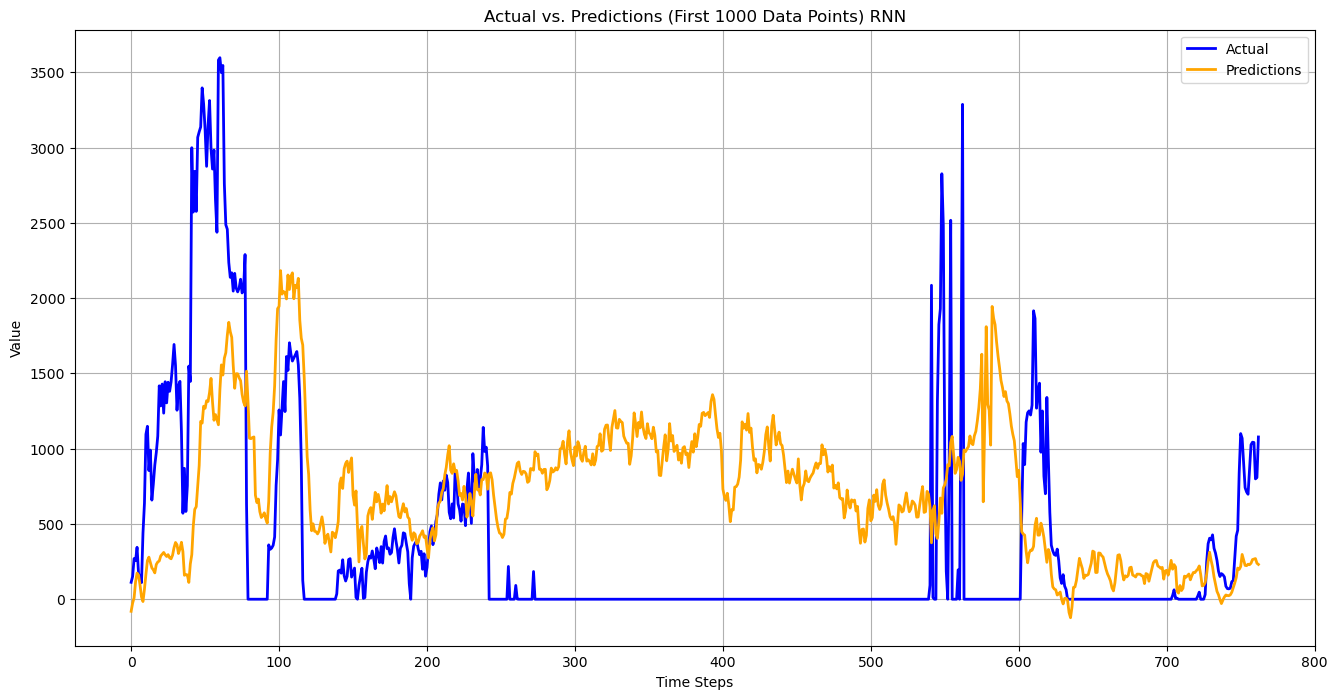

In [557]:
def plot_predictions_comparison(actual, prediction, model_name, num_points=1000):
    plt.figure(figsize=(16, 8))  # Increased figure size for better visibility

    # Select the first 1000 elements for plotting
    actual_plot = y_test[:num_points]
    prediction_plot = prediction[:num_points]

    # Create the plot
    plt.plot(actual_plot, label='Actual', color='blue', linewidth=2)
    plt.plot(prediction_plot, label='Predictions', color='orange', linewidth=2)

    plt.title('Actual vs. Predictions (First 1000 Data Points) ' + model_name)
    plt.xlabel('Time Steps')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()



# Plot the first 1000 actual and predicted values
plot_predictions_comparison(y_test, prediction_rnn, 'RNN')